# 🧠 Exploring Spiking Dynamics in *In Vitro* Neuronal Networks

Welcome to the project! 

In this notebook you will load real electrophysiology data recorded from iPSC-derived neurons growing on a high-density multi-electrode array (MEA), visualise their activity, and compute a set of standard metrics used in computational neuroscience.

Take your time, read the comments, and don't be afraid to experiment!

## 🔍 Step 1: Explore the data folder before writing any code!

Before we touch Python, let's orient ourselves:

- **How many files are there?** Each file corresponds to one recording (one network, one day).
- **What does the filename mean?** Look for clues: patient ID, DIV (Days *In Vitro* = how old the culture is), well number.
- **Open the `Rasterplots` folder.** Each image shows neuron activity over time — each row is one neuron, each dot is one spike. What patterns do you notice? Are neurons firing randomly, or together?
- **What do you expect to find in the data file itself?**

> 💡 *Spend a few minutes exploring before running any code!*

## ⚙️ Quick Setup

First we install and import the Python libraries we need:
- **`numpy`** — the workhorse for numerical computing (arrays, maths)
- **`matplotlib`** — for plotting graphs and figures
- **`pickle`** — to load our data file (it's stored in Python's binary format)

In [ ]:
# This line installs the libraries we need.
# The '!' at the start tells Jupyter to run this as a terminal command, not Python.
# You only need to run this once — after that the libraries are already installed.
!pip install numpy matplotlib

In [38]:
# 'import' makes a library available for use in this notebook.
# We also give them short nicknames (np, plt) so we don't have to type the full name every time.

import pickle          # for loading .pkl (pickle) files
import numpy as np     # 'np' is the standard nickname for numpy
import matplotlib.pyplot as plt  # 'plt' is the standard nickname for matplotlib's plotting module

print('Libraries imported successfully!')  # always good to confirm things worked

Libraries imported successfully!


In [41]:
# This cell customises the appearance of all our plots.
# Think of it as setting a 'style sheet' for the whole notebook.
# plt.rcParams is a dictionary of default settings — we update it once here
# so every plot automatically looks clean and pretty. You can of course change this to your liking! :)

plt.rcParams.update({
    'figure.dpi': 150,            # screen resolution (dots per inch) — higher = sharper
    'savefig.dpi': 300,           # resolution when saving to file (300 dpi = print quality)
    'figure.facecolor': 'white',  # white background for the whole figure
    'axes.facecolor': 'white',    # white background for the plot area
    'axes.spines.top': False,     # remove the top border line (cleaner look)
    'axes.spines.right': False,   # remove the right border line
    'axes.linewidth': 1.2,        # thickness of the remaining axis lines
    'font.size': 12,              # default text size
    'axes.titlesize': 13,         # size of plot titles
    'axes.titleweight': 'bold',   # make titles bold
    'axes.labelsize': 13,         # size of axis labels (x-label, y-label)
    'axes.labelweight': 'bold',   # make axis labels bold
    'xtick.labelsize': 10,        # size of x-axis tick numbers
    'ytick.labelsize': 10,        # size of y-axis tick numbers
    'legend.fontsize': 8,         # size of legend text
    'xtick.direction': 'out',     # tick marks point outward
    'ytick.direction': 'out',
})

print('Plot style configured!')

Plot style configured!


## 📂 Load the Data

Our data is stored as a **pickle file** (`.pkl`). 

Update `FILE_PATH` below to point to the file on your laptop.

In [44]:
# ---- Change this path to wherever you saved the data file on your laptop! ----
FILE_PATH = r'C:\Users\Giuli\Documents\Recover\BIORTC_Nigeria\2026\Data\In_Vitro\GBM_Progression_Data\PatientA_N0-4\ID1814_N0_DIV48_DATE20240618_1349_spontaneous_Patient1.raw_processed_info_metrics.pkl'

# 'open(FILE_PATH, "rb")' opens the file in read-binary mode ('rb').
# We use a 'with' statement so Python automatically closes the file when done —
# even if something goes wrong. Good practice!
with open(FILE_PATH, 'rb') as f:
    data = pickle.load(f)   

# The loaded object is a Python *dictionary* — like a lookup table with named slots.
# Let's see what keys (slot names) it has:
print('Keys in the data dictionary:', list(data.keys()))
print()
print('Think of a dictionary as a book library:')
print('  each key is a book title, and data[key] is what is inside that book.')

Keys in the data dictionary: ['EXPERIMENT_DURATION', 'SPIKES', 'mTE']

Think of a dictionary as a book library:
  each key is a book title, and data[key] is what is inside that book.


In [46]:
# Let's unpack the three entries from the dictionary into separate variables.
# This makes them easier to work with.

spikes   = data['SPIKES']              # a structured numpy array — every detected spike
mte      = data['mTE']                 # transfer entropy graph (we'll use this in the next notebook)
duration = data['EXPERIMENT_DURATION'] # total recording length, in seconds

# The SPIKES array has named columns (called 'fields'), just like a spreadsheet.
# Let's extract the ones we need:
spike_times = spikes['Spike_Time']  # when each spike occurred (in ms)
unit_ids    = spikes['UnitIdx']     # which neuron fired that spike (integer neuron ID)

# np.unique() returns the list of unique neuron IDs — i.e. which neurons are present
neurons   = np.unique(unit_ids)
n_neurons = len(neurons)   # how many distinct neurons were recorded

# Print a summary so we know our data loaded correctly
print(f'Recording duration : {duration:.2f} s')
print(f'Total spikes       : {len(spikes)}')
print(f'Number of neurons  : {n_neurons}')
print()
print('Fields in the SPIKES array:', spikes.dtype.names)
print('Example spike (Electrode, Spike_Time, UnitIdx):', spikes[0])

Recording duration : 86.76 s
Total spikes       : 15871
Number of neurons  : 57

Fields in the SPIKES array: ('Electrode', 'Spike_Time', 'UnitIdx')
Example spike (Electrode, Spike_Time, UnitIdx): ('17631', 15.7, 20)


## 📊 Part 1: Visualise the Raw Activity

Before computing any numbers, it always pays to *look* at the data. We'll make two classic neuroscience visualisations:

1. **Raster plot** — each row is one neuron, each dot is one spike. Gives an immediate sense of which neurons are active and whether they fire together.
2. **Population firing rate** — how many neurons are active at each moment in time. Reveals network-wide rhythms and bursts.

### 🔵 Raster Plot

A raster plot is the most fundamental way to display spike train data. Each horizontal row represents one neuron. Every time that neuron fires a spike, a small dot (or tick) is drawn at the corresponding time. Vertical columns of dots suggest that many neurons fired together!

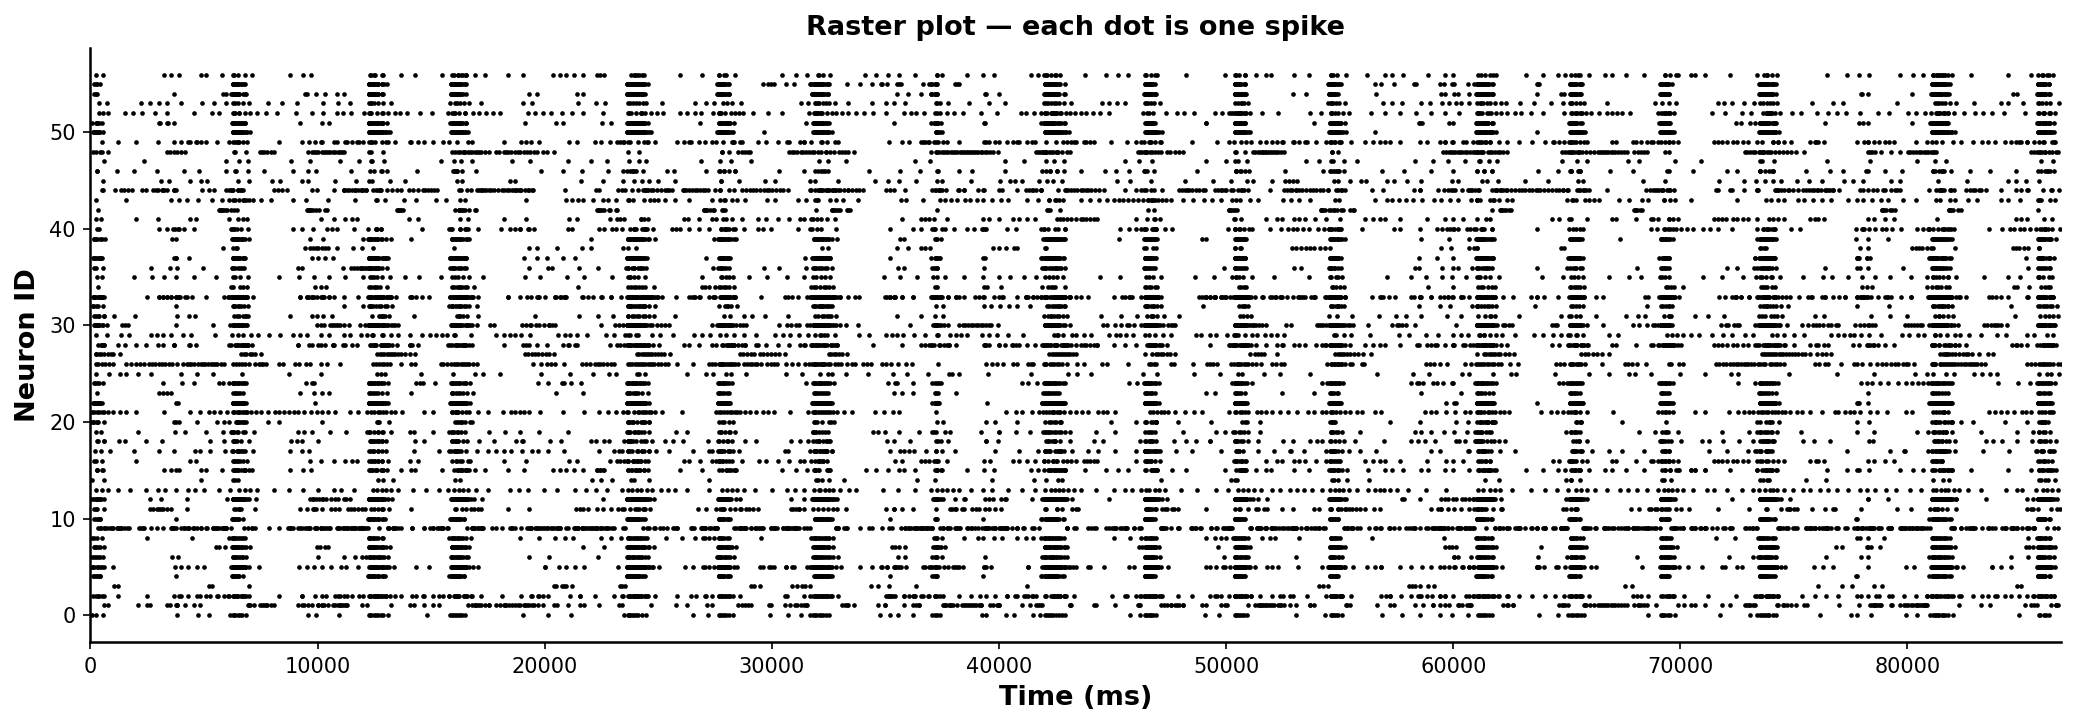

In [48]:
# --- Raster plot ---
# ax.scatter() draws one dot for each spike.
#   x-axis: spike_times  → when the spike happened
#   y-axis: unit_ids     → which neuron fired

fig, ax = plt.subplots(figsize=(14, 5))  # create a figure that is 14 inches wide, 5 tall

ax.scatter(spike_times, unit_ids, s=5, c='black', linewidths=0)

ax.set_xlabel('Time (ms)')    # always label your axes!
ax.set_ylabel('Neuron ID')
ax.set_title('Raster plot — each dot is one spike')
ax.set_xlim(0, duration*1e3)      # make sure the x-axis spans the full recording

plt.tight_layout()  # automatically adjust spacing so labels don't get cut off
plt.show()          # display the figure

# 👉 Look at the plot: do you see vertical 'stripes' of activity?
#    Those stripes are moments when many neurons fire at the same time — network bursts!

In [49]:
# --- Population firing rate ---
# Instead of individual spikes, we want to know: at each moment, how many neurons are active?
#
# To do this we divide time into small 'bins' (here 50 ms each) and count how many
# spikes fall into each bin. This is called a histogram.

bin_size = 50  # bin width in milliseconds — try changing this to 10 or 100 and see what happens!

# np.arange creates an array of evenly spaced values:
#   start = 0 ms, stop = end of recording in ms, step = bin_size
bins = np.arange(0, duration*1e3 + bin_size, bin_size)

# np.histogram counts how many spike_times fall into each bin.
# pop_fr  = array of spike counts per bin  (this is what we want to plot)
# bin_edges = the edges of each bin        (we use these to find bin centres)
pop_fr, bin_edges = np.histogram(spike_times, bins=bins)

# The bin edges give us the start and end of each bin.
# The 'centre' of each bin is the average of its two edges:
#   e.g. bin from 0 to 50 ms  →  centre at 25 ms
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

print(f'Bin size : {bin_size} ms')
print(f'Number of bins : {len(pop_fr)}')
print(f'Max population firing rate: {pop_fr.max()} spikes in a single {bin_size} ms bin')

Bin size : 50 ms
Number of bins : 1736
Max population firing rate: 92 spikes in a single 50 ms bin


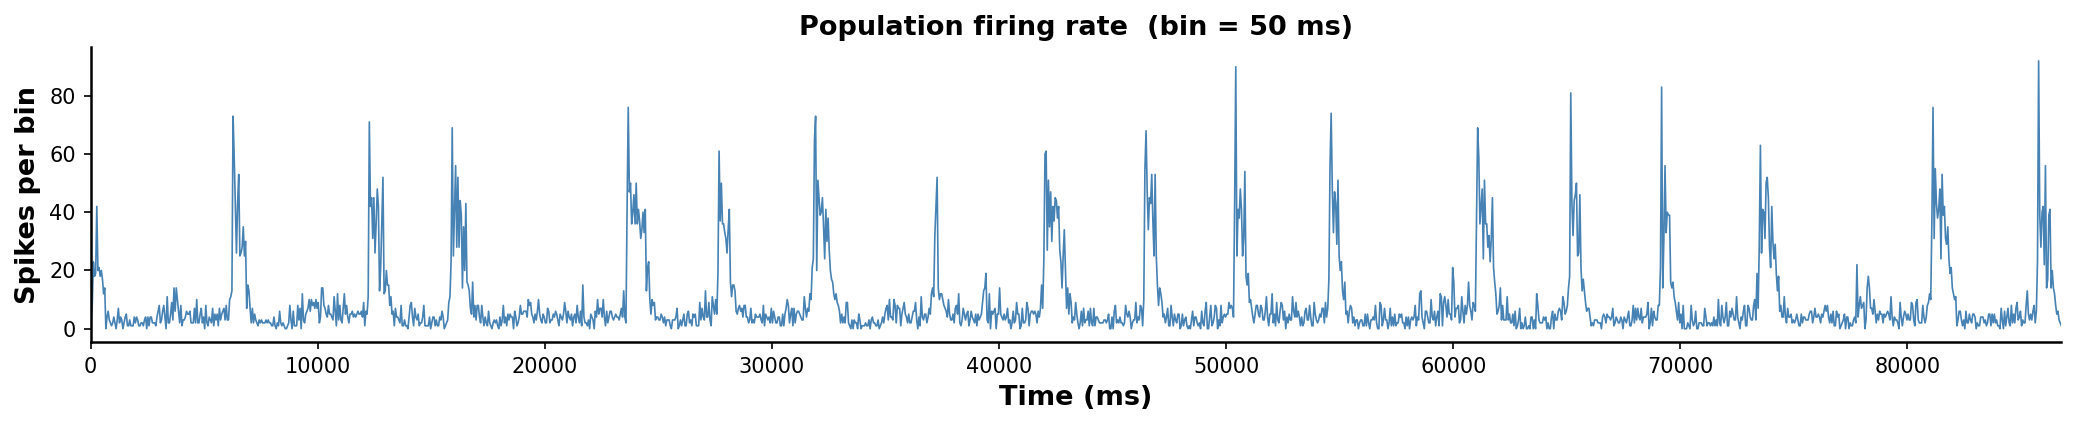

In [50]:
# --- Plot the population firing rate ---
# ax.plot() draws a line connecting each (time, spike_count) point.
# lw = line width

fig, ax = plt.subplots(figsize=(14, 3))  # wide and short — good for time series

ax.plot(bin_centres, pop_fr, lw=0.8, color='steelblue')

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Spikes per bin')
ax.set_title(f'Population firing rate  (bin = {bin_size} ms)')
ax.set_xlim(0, duration*1e3)

plt.tight_layout()
plt.show()

# 👉 Compare this to the raster plot above.
#    The peaks in the population firing rate should line up with the dense vertical
#    stripes in the raster plot — those are your network bursts!

### 💬 Observations

Look at the two plots you just made and think about the following:

- Are there clear **network bursts** (periods of high activity)? How many do you see?
- Is the activity **rhythmic** (bursts occurring at regular intervals) or **irregular**?
- Are there neurons that seem to **never fire** (missing rows in the raster)?
- What might cause a network of neurons to fire in synchronised bursts?

> 🧪 *In healthy developing neuronal networks, a bit of synchronised bursting is normal and actually important for network maturation. However, too much or too little synchrony can be a sign of disease.*

## 📐 Part 2: Quantify the Activity

We'll now compute standard metrics at two levels:

1. **Neuron level** — what does each individual neuron do? How fast does it fire? How regular? Does it burst?
2. **Network level** — how does the whole population behave together? Are bursts synchronised?

### 🔬 Neuron-Level Metrics

For each neuron we will compute:

| Metric | What it tells us |
|---|---|
| **Firing rate (FR)** | How active is the neuron overall? (spikes per second, Hz) |
| **Inter-spike interval (ISI)** | How much time passes between consecutive spikes? |
| **CV of ISI** | How *regular* is the firing? (0 = perfectly regular, >1 = bursty) |
| **Burst rate** | How often does the neuron fire in rapid bursts? |
| **Inter-burst interval (IBI)** | How much time passes between consecutive bursts? |

In [52]:
# --- Firing rate per neuron ---
# Firing rate = total number of spikes / recording duration
# Units: spikes per second = Hertz (Hz)
#
# We store the result in a *dictionary* so we can look up any neuron's firing rate
# by its ID: firing_rates[neuron_id] → firing rate in Hz

firing_rates = {}  # empty dictionary — we'll fill it in the loop below

for nid in neurons:  # loop over every unique neuron ID

    # Get all spikes that belong to this neuron by filtering on UnitIdx
    spikes_this_neuron = spikes[spikes['UnitIdx'] == nid]

    # The number of spikes is just the length of this filtered array
    n_spikes = len(spikes_this_neuron)

    # Divide by duration (converted from ms to seconds) to get Hz
    firing_rates[nid] = n_spikes / (duration)  # Hz

# Convert the dictionary values to a numpy array so we can do statistics on them
fr_values = np.array(list(firing_rates.values()))

print(f'Mean firing rate   : {fr_values.mean():.2f} Hz')
print(f'Median firing rate : {np.median(fr_values):.2f} Hz')
print(f'Range              : {fr_values.min():.2f} – {fr_values.max():.2f} Hz')
print()
print('(Mean > Median suggests a few very active neurons pull the average up — a skewed distribution)')

Mean firing rate   : 3.21 Hz
Median firing rate : 2.82 Hz
Range              : 0.52 – 9.49 Hz

(Mean > Median suggests a few very active neurons pull the average up — a skewed distribution)


In [54]:
# --- Inter-spike interval (ISI) per neuron ---
# The ISI is the time between two consecutive spikes of the SAME neuron.
# It tells us about the *temporal pattern* of firing, not just the rate.
#
# Steps for each neuron:
#   1. Extract all spike times for that neuron
#   2. Sort them in time order (they usually already are, but good to be safe)
#   3. Compute the differences between consecutive times → that's the ISI array

isis = {}  # dictionary: neuron ID → array of ISI values (in ms)

for nid in neurons:
    # Get all spikes for this neuron and extract their times, sorted
    spikes_this_neuron = spikes[spikes['UnitIdx'] == nid]
    t = np.sort(spikes_this_neuron['Spike_Time'])
    
    # We need at least 2 spikes to compute a difference!
    if len(t) > 1:
        # np.diff computes the time between each consecutive pair of spikes
        isis[nid] = np.diff(t)  # units: milliseconds

# Compute the mean ISI per neuron first, then average across neurons.
# This gives each neuron equal weight — otherwise neurons with more spikes
# would contribute more values to the pool and bias the mean.
mean_isi_per_neuron = np.array([np.mean(isi) for isi in isis.values()])

print(f'Mean ISI (averaged per neuron)   : {mean_isi_per_neuron.mean():.1f} ms')
print(f'Median ISI (averaged per neuron) : {np.median(mean_isi_per_neuron):.1f} ms')
print()
print('(A short ISI = spikes very close together = fast firing or bursting)')

Mean ISI (averaged per neuron)   : 440.7 ms
Median ISI (averaged per neuron) : 354.0 ms

(A short ISI = spikes very close together = fast firing or bursting)


In [55]:
# --- Coefficient of Variation of the ISI (CV ISI) ---
#
# The CV is a normalised measure of variability: CV = standard deviation / mean
# Because we divide by the mean, the CV is dimensionless — we can compare neurons
# that fire at very different rates.
#
# Interpretation:
#   CV ≈ 0   → spikes are perfectly regular (like a metronome)
#   CV ≈ 1   → random (Poisson) firing — each spike is independent of the last
#   CV >> 1  → highly irregular / bursty firing — short ISIs within bursts,
#               long ISIs between bursts, making the variance very large

cv_isi = {}  # dictionary: neuron ID → CV ISI value

for nid, isi in isis.items():  # loop over the isis dictionary we built above

    if len(isi) > 1:  # need at least 2 ISI values to compute std
        # isi.std()  = standard deviation of this neuron's ISIs
        # isi.mean() = mean ISI
        cv_isi[nid] = isi.std() / isi.mean()

cv_values = np.array(list(cv_isi.values()))

print(f'Mean CV ISI   : {cv_values.mean():.2f}')
print(f'Median CV ISI : {np.median(cv_values):.2f}')
print()
print('CV > 1 for most neurons → the network is firing in a bursty (not random) manner!')

Mean CV ISI   : 1.83
Median CV ISI : 1.62

CV > 1 for most neurons → the network is firing in a bursty (not random) manner!


In [57]:
BURST_SPIKES = 4
BURST_WINDOW = 50

burst_rates  = {}
burst_trains = {}

for nid in neurons:

    t = np.sort(spike_times[unit_ids == nid])

    if len(t) < BURST_SPIKES:
        burst_rates[nid]  = 0.0
        burst_trains[nid] = []
        continue

    bursts          = []
    in_burst        = False
    burst_start_idx = 0

    i = 0
    while i < len(t):  # now we go all the way to the last spike

        if i <= len(t) - BURST_SPIKES and t[i + BURST_SPIKES - 1] - t[i] <= BURST_WINDOW:
            # We still have enough spikes ahead, and they fit within the burst window.
            # If we weren't in a burst yet, this is where one starts.
            if not in_burst:
                in_burst = True
                burst_start_idx = i
            i += 1

        else:
            if in_burst:
                # The burst just ended — close it at the previous spike (last one still in window)
                bursts.append((t[burst_start_idx], t[i - 1]))
                in_burst = False
            i += 1

    # Close any burst still open at the end of the spike train
    if in_burst:
        bursts.append((t[burst_start_idx], t[-1]))

    burst_trains[nid] = bursts
    burst_rates[nid]  = len(bursts) / (duration)

br_values  = np.array(list(burst_rates.values()))
n_bursting = np.sum(br_values > 0)

print(f'Neurons with at least one burst : {n_bursting} / {n_neurons}')
print(f'Mean burst rate (bursting neurons only) : {br_values[br_values > 0].mean():.3f} bursts/s')

Neurons with at least one burst : 26 / 57
Mean burst rate (bursting neurons only) : 0.155 bursts/s


In [60]:
# --- Inter-burst interval (IBI) and its CV ---
#
# Just as ISI measures time between spikes, IBI measures time between bursts.
# We define IBI as the time from the START of one burst to the START of the next.
#
# CV of IBI tells us how regular the bursting rhythm is:
#   Low CV  → bursts occur at regular intervals (rhythmic bursting)
#   High CV → bursts are irregularly spaced

ibi_all = []
cv_ibi  = {}

for nid, bursts in burst_trains.items():

    if len(bursts) > 1:

        # IBI = time from the END of one burst to the START of the next
        # This captures the true 'silence' between bursts, not the burst duration itself
        burst_ends   = np.array([b[1] for b in bursts[:-1]])  # end times of all but the last burst
        burst_starts = np.array([b[0] for b in bursts[1:]])   # start times of all but the first burst
        ibi = burst_starts - burst_ends   # units: milliseconds

        ibi_all.append(ibi)
        cv_ibi[nid] = ibi.std() / ibi.mean() if ibi.mean() > 0 else np.nan

if ibi_all:
    all_ibis      = np.concatenate(ibi_all)
    cv_ibi_values = np.array([v for v in cv_ibi.values() if not np.isnan(v)])
    print(f'Median IBI   : {np.median(all_ibis):.2f} ms')
    print(f'Mean CV IBI  : {cv_ibi_values.mean():.2f}')
else:
    print('Not enough bursts detected to compute IBI (each neuron needs at least 2 bursts).')

Median IBI   : 773.35 ms
Mean CV IBI  : 0.62


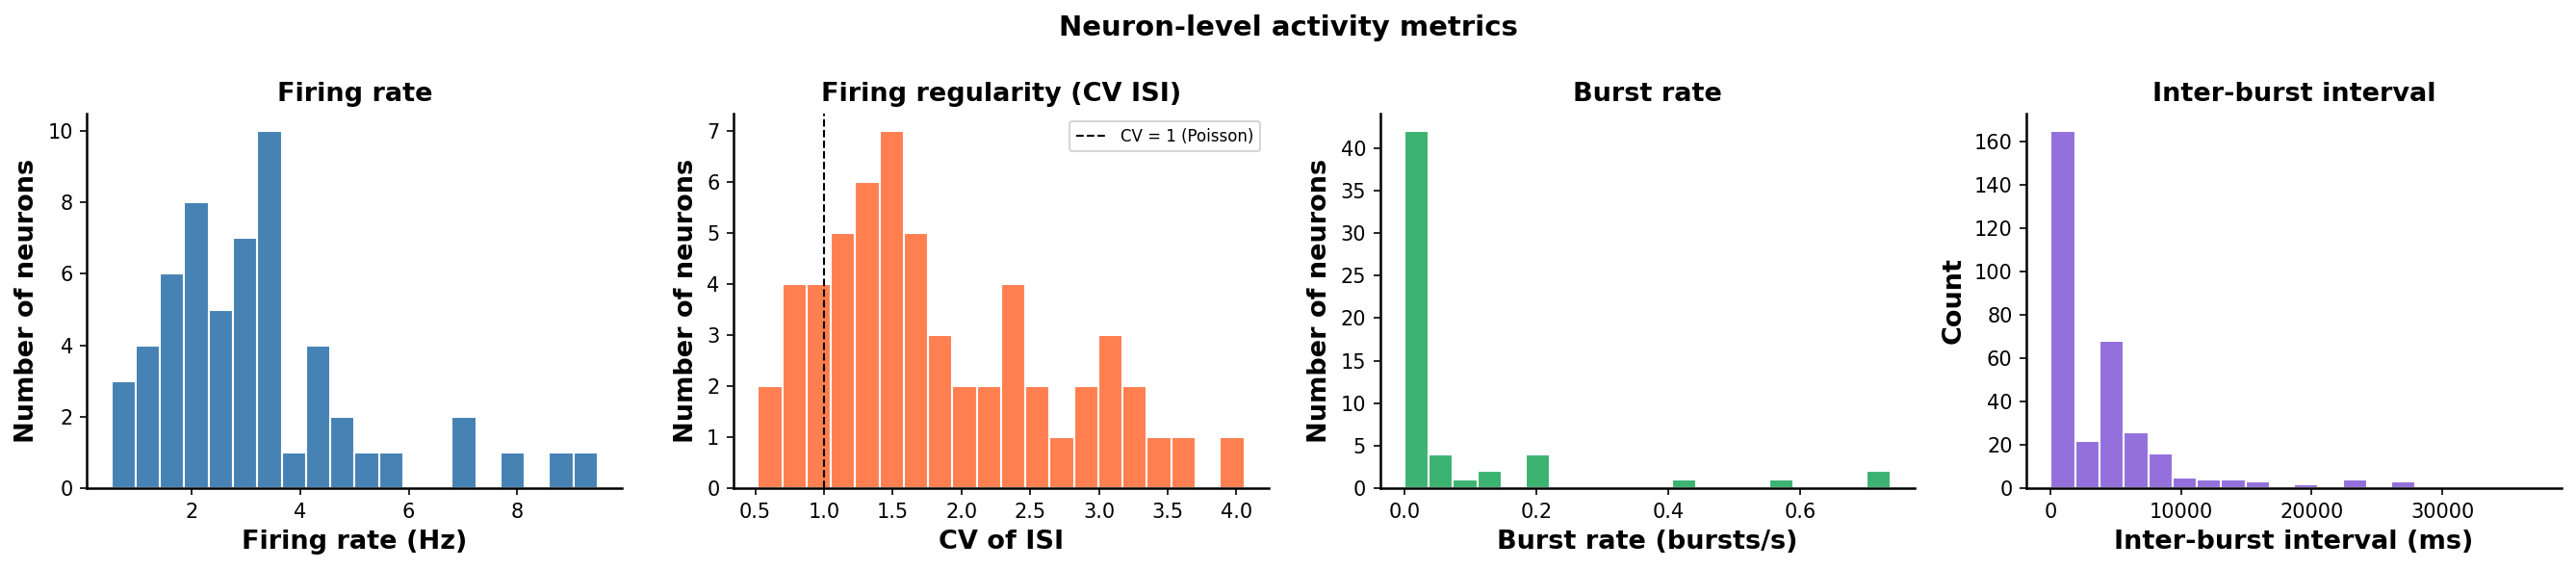

In [61]:
# --- Plot distributions of all neuron-level metrics ---
#
# A histogram shows how values are distributed across neurons.
# The x-axis is the metric value, the y-axis is 'how many neurons have that value'.
#
# plt.subplots(1, 4) creates a grid of 1 row and 4 columns of subplots.
# 'axes' is an array of 4 Axes objects — we index them as axes[0], axes[1], etc.

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# --- Plot 1: Firing rate distribution ---
axes[0].hist(fr_values, bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Firing rate (Hz)')
axes[0].set_ylabel('Number of neurons')
axes[0].set_title('Firing rate')

# --- Plot 2: CV ISI distribution ---
axes[1].hist(cv_values, bins=20, color='coral', edgecolor='white')
# Add a vertical dashed line at CV=1 (Poisson reference)
axes[1].axvline(1, color='k', linestyle='--', lw=1, label='CV = 1 (Poisson)')
axes[1].set_xlabel('CV of ISI')
axes[1].set_ylabel('Number of neurons')
axes[1].set_title('Firing regularity (CV ISI)')
axes[1].legend()

# --- Plot 3: Burst rate distribution ---
axes[2].hist(br_values, bins=20, color='mediumseagreen', edgecolor='white')
axes[2].set_xlabel('Burst rate (bursts/s)')
axes[2].set_ylabel('Number of neurons')
axes[2].set_title('Burst rate')

# --- Plot 4: IBI distribution ---
if ibi_all:
    axes[3].hist(all_ibis, bins=20, color='mediumpurple', edgecolor='white')
    axes[3].set_xlabel('Inter-burst interval (ms)')
    axes[3].set_ylabel('Count')
    axes[3].set_title('Inter-burst interval')
else:
    # If no IBI data, display a message instead of an empty plot
    axes[3].text(0.5, 0.5, 'No IBI data', ha='center', va='center',
                 transform=axes[3].transAxes, fontsize=12, color='grey')

plt.suptitle('Neuron-level activity metrics', fontsize=14, fontweight='bold')
plt.tight_layout()  # prevent subplots from overlapping
plt.show()

# 👉 Questions to think about:
#    - Is the firing rate distribution skewed? What does that mean?
#    - Are most neurons above or below CV = 1? What does that tell you?
#    - Do most neurons burst, or only a few?

### 🌐 Network-Level Metrics

Now we zoom out from individual neurons and look at the **collective behaviour** of the entire network.

#### Network bursts
A **network burst** is a moment when a large fraction of neurons fire together. We detect these by looking for peaks in the population firing rate that exceed a threshold.

#### Pairwise correlation
The **Pearson correlation coefficient** between two neurons measures how similarly they fire over time:
- **+1** → they always fire at exactly the same moment
- **0** → their firing is completely unrelated
- **−1** → when one fires, the other is silent

Averaging this across all pairs gives a single number for overall network synchrony.

In [73]:
# --- Detect network bursts from the population firing rate ---
#
# Strategy: define a threshold = mean + 1 standard deviation of the population firing rate.
# Any time bin where pop_fr exceeds this threshold is considered part of a network burst.
# Consecutive bins above the threshold form a single burst event.

# Calculate the threshold
threshold = pop_fr.mean() + pop_fr.std()
# pop_fr.mean() = average number of spikes per bin across the whole recording
# pop_fr.std()  = standard deviation — a measure of how much pop_fr varies
# Together: we only flag bins that are substantially above average

# Create a boolean (True/False) array: True where pop_fr exceeds the threshold
above = pop_fr > threshold

# Walk through the 'above' array and find the start and end of each continuous run of Trues
network_bursts = []  # will store (start_time, end_time) for each network burst
in_nb    = False    # flag: are we currently inside a network burst?
nb_start = 0        # time when the current network burst started

for i, val in enumerate(above):  # enumerate gives us both the index (i) and the value (val)

    if val and not in_nb:     # just crossed above the threshold → burst start
        in_nb    = True
        nb_start = bin_centres[i]

    elif not val and in_nb:   # just dropped below the threshold → burst end
        in_nb = False
        network_bursts.append((nb_start, bin_centres[i - 1]))

# Handle the edge case where the recording ends while still in a burst
if in_nb:
    network_bursts.append((nb_start, bin_centres[-1]))

# Compute duration of each network burst
nb_durations = np.array([end - start for start, end in network_bursts])  # in ms

# Compute spike rate within each network burst (spikes / duration)
nb_spike_rates = []
for start, end in network_bursts:
    # Boolean mask: True for spikes that occurred during this burst
    mask = (spike_times >= start) & (spike_times <= end)
    dur_s = (end - start) / 1000  # convert ms to seconds
    if dur_s > 0:
        nb_spike_rates.append(mask.sum() / dur_s)  # spikes per second during the burst
nb_spike_rates = np.array(nb_spike_rates)

print(f'Detection threshold         : {threshold:.1f} spikes / {bin_size} ms bin')
print(f'Number of network bursts    : {len(network_bursts)}')
if len(nb_durations) > 0:
    print(f'Mean network burst duration : {nb_durations.mean():.0f} ms')
    print(f'Mean NB spike rate          : {nb_spike_rates.mean():.1f} spikes/s')


Detection threshold         : 22.2 spikes / 50 ms bin
Number of network bursts    : 30
Mean network burst duration : 285 ms
Mean NB spike rate          : 867.9 spikes/s


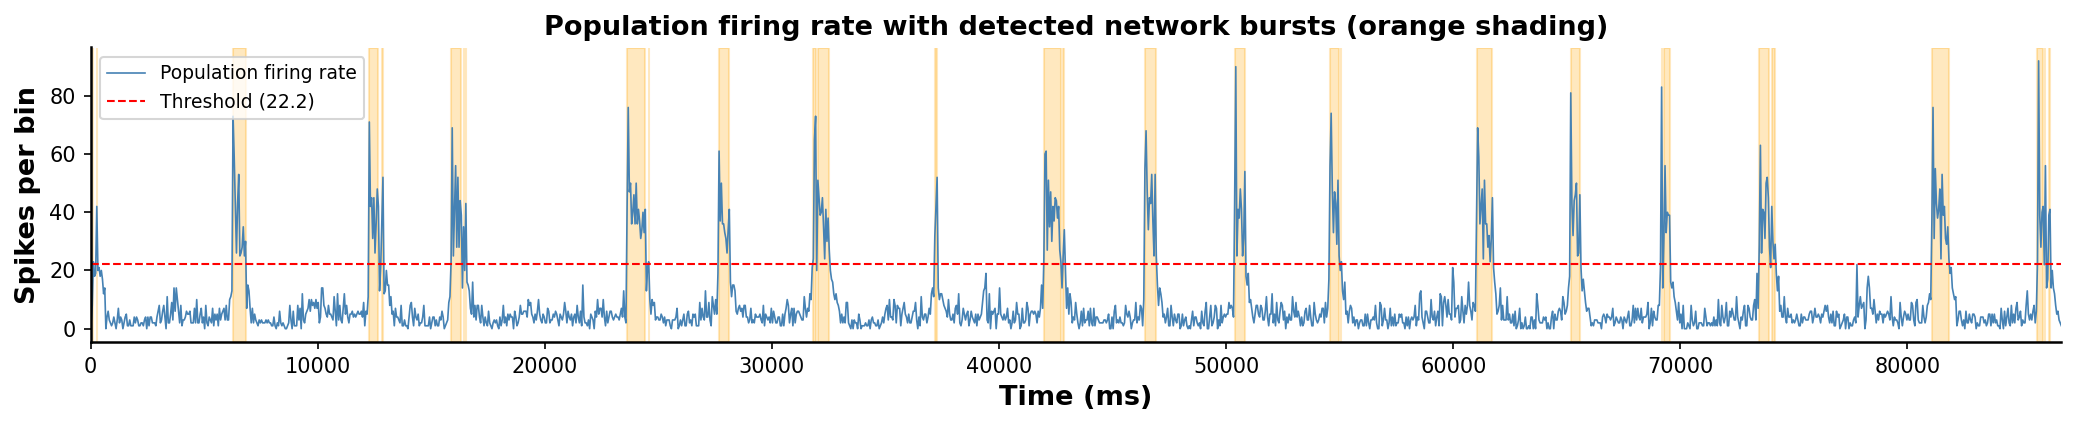

In [74]:
# --- Plot the population firing rate with network bursts highlighted ---
fig, ax = plt.subplots(figsize=(14, 3))

ax.plot(bin_centres, pop_fr, lw=0.8, color='steelblue', label='Population firing rate')

# Draw the threshold as a horizontal dashed line
ax.axhline(threshold, color='red', lw=1, linestyle='--', label=f'Threshold ({threshold:.1f})')

# Shade the time periods identified as network bursts in orange
for start, end in network_bursts:
    ax.axvspan(start, end, alpha=0.25, color='orange')  # axvspan = vertical shaded region

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Spikes per bin')
ax.set_title('Population firing rate with detected network bursts (orange shading)')
ax.set_xlim(0, duration*1e3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# 👉 Does the orange shading capture the peaks you saw earlier?
#    Try changing the threshold (e.g. mean + 2*std) and re-run — how does it affect the result?

Number of neuron pairs        : 1596
Mean pairwise correlation     : 0.065
Median pairwise correlation   : 0.042

(nan values arise for neurons with zero variance — e.g. only 1 spike — and are ignored)


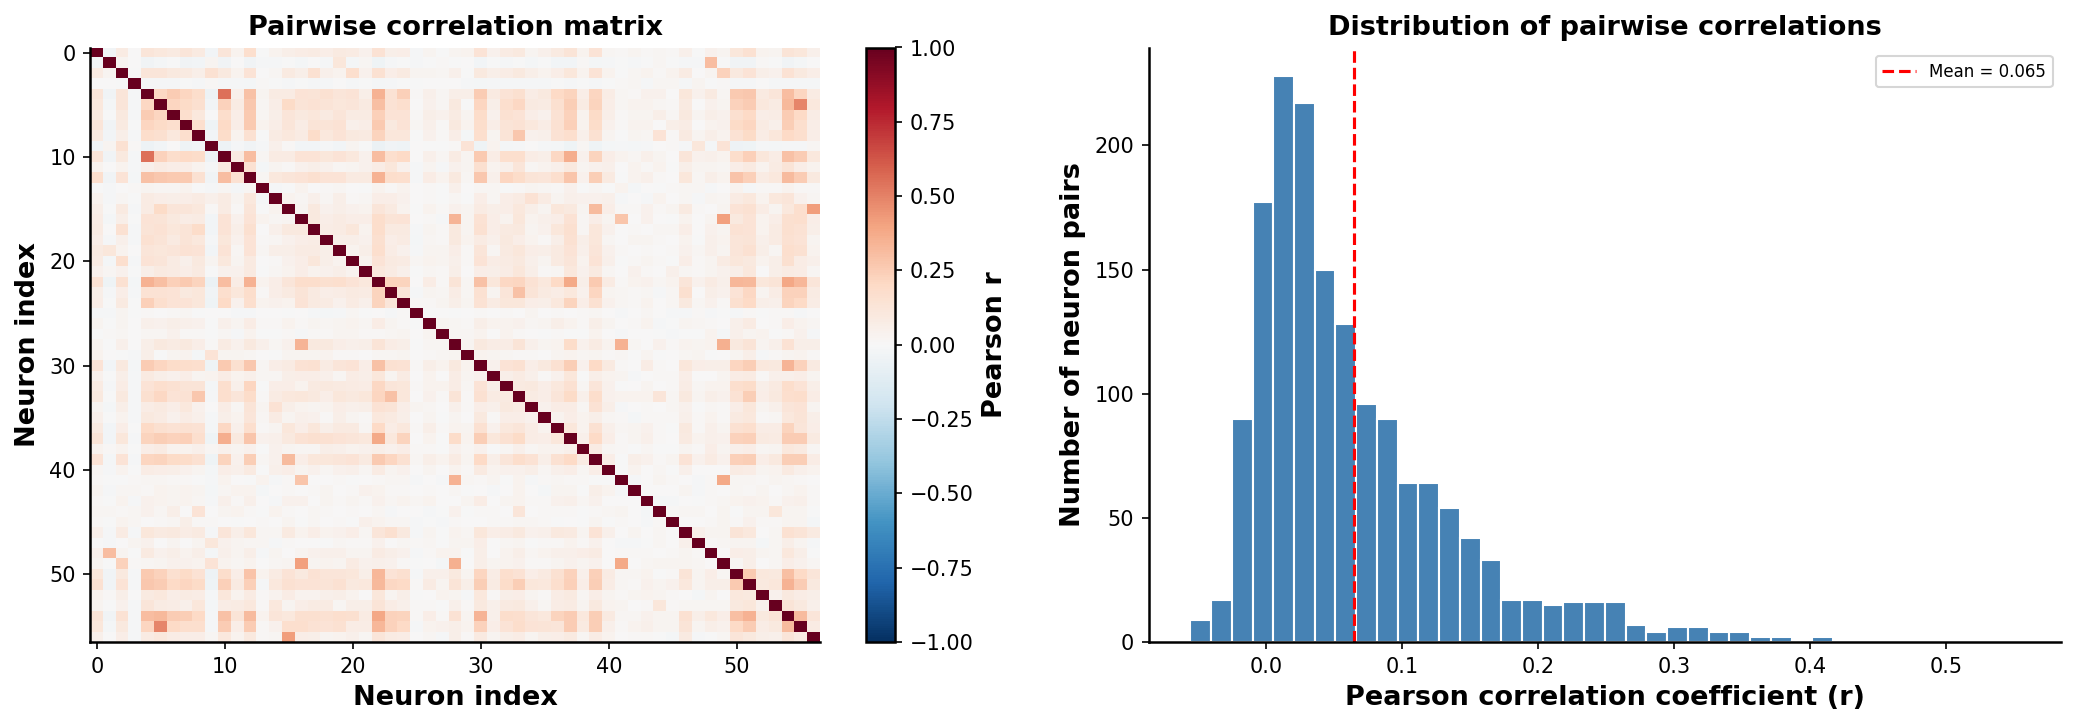

In [75]:
# --- Pairwise correlation between all neurons ---
#
# To compute correlations we first convert the spike train of each neuron
# into a *spike count vector*: divide time into small bins (10 ms) and count
# how many spikes each neuron fired in each bin.
# This gives us an (n_neurons × n_bins) matrix where each row is one neuron's
# activity timeseries.
#
# Then np.corrcoef computes the Pearson correlation between every pair of rows,
# giving us an (n_neurons × n_neurons) correlation matrix.

bin_size_corr = 10  # 10 ms bins — fine enough to capture spike co-occurrence

# Create the time bin edges (same idea as before)
bins_corr = np.arange(0, duration*1e3 + bin_size_corr, bin_size_corr)

# Pre-allocate the spike count matrix with zeros.
# Shape: (n_neurons rows) × (number of bins columns)
# dtype=float32 saves memory compared to float64 (less precision, but fine here)
spike_matrix = np.zeros((n_neurons, len(bins_corr) - 1), dtype=np.float32)

# Fill in the matrix: one row per neuron
for i, nid in enumerate(neurons):  # enumerate gives index i and neuron id nid
    t = spike_times[unit_ids == nid]         # spike times for this neuron
    spike_matrix[i], _ = np.histogram(t, bins=bins_corr)
    # np.histogram returns (counts, bin_edges) — we only need counts so we discard
    # bin_edges with '_' (Python convention for 'I don't need this variable')

# Compute pairwise Pearson correlation
# np.corrcoef returns a symmetric matrix: entry [i, j] = correlation between neuron i and j
# The diagonal is always 1.0 (a neuron is perfectly correlated with itself)
corr_matrix = np.corrcoef(spike_matrix)

# Extract the upper triangle (above the diagonal) to avoid counting each pair twice
# np.triu_indices(n, k=1) returns the indices of all elements above the main diagonal
upper_tri = corr_matrix[np.triu_indices(n_neurons, k=1)]

print(f'Number of neuron pairs        : {len(upper_tri)}')
print(f'Mean pairwise correlation     : {np.nanmean(upper_tri):.3f}')
print(f'Median pairwise correlation   : {np.nanmedian(upper_tri):.3f}')
print()
print('(nan values arise for neurons with zero variance — e.g. only 1 spike — and are ignored)')

# --- Plot the correlation matrix and distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of the full correlation matrix
# vmin=-1, vmax=1 anchors the colour scale to the full range of possible correlations
# cmap='RdBu_r' : red = positive, white = zero, blue = negative
im = axes[0].imshow(corr_matrix, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[0], label='Pearson r')  # add a colour bar legend
axes[0].set_title('Pairwise correlation matrix')
axes[0].set_xlabel('Neuron index')
axes[0].set_ylabel('Neuron index')

# Histogram of all pairwise correlations
valid = upper_tri[~np.isnan(upper_tri)]  # remove NaN values before plotting
axes[1].hist(valid, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(np.nanmean(upper_tri), color='red', linestyle='--',
                label=f'Mean = {np.nanmean(upper_tri):.3f}')
axes[1].set_xlabel('Pearson correlation coefficient (r)')
axes[1].set_ylabel('Number of neuron pairs')
axes[1].set_title('Distribution of pairwise correlations')
axes[1].legend()

plt.tight_layout()
plt.show()

# 👉 Look at the heatmap: do you see any block structure?
#    Groups of neurons that are highly correlated with each other form 'assemblies'.
#    The distribution: is it centred near 0 (uncorrelated) or shifted positive (synchronised)?

In [76]:
# 🎉 Well done for making it this far!
#
# You have just:
#   ✅ Loaded real neurophysiology data from a pickle file
#   ✅ Visualised spike trains with a raster plot
#   ✅ Computed population firing rate
#   ✅ Quantified single-neuron firing rate, ISI, CV ISI, burst rate, and IBI
#   ✅ Detected network bursts with a threshold approach
#   ✅ Computed pairwise correlations to assess network synchrony
#
# Next steps (try on your own!):
#   → Load a different file (different DIV or patient) and compare the metrics
#   → Change the burst detection parameters (BURST_SPIKES, BURST_WINDOW) — how sensitive is the result?
#   → Try a different correlation bin size (5 ms vs 50 ms) — does it change the picture?
#   → Open Explore_data_networks.ipynb to analyse the transfer entropy graph!
print('Notebook complete!')

Notebook complete!
